In [319]:
pip install torch torchvision torchaudio 

Note: you may need to restart the kernel to use updated packages.


<h1> Setting Up Dataset and Weights Paths </h1>

In [1]:
import os

# Set up the base directory for dataset and weights
HOME = os.getcwd()
print("HOME:", HOME)

# Define dataset and weights directory
DATASET_PATH = os.path.join(HOME, "dataset")
IMAGES_PATH = os.path.join(DATASET_PATH, "images")
WEIGHTS_PATH = os.path.join(HOME, "weights")

# Create necessary directories if they don't exist
os.makedirs(WEIGHTS_PATH, exist_ok=True)
os.makedirs(IMAGES_PATH, exist_ok=True)

print(f"✅ Dataset Path: {DATASET_PATH}")
print(f"✅ Images Path: {IMAGES_PATH}")
print(f"✅ Weights Path: {WEIGHTS_PATH}")

HOME: /Users/ma/Documents/samThesis/segment-anything/notebooks
✅ Dataset Path: /Users/ma/Documents/samThesis/segment-anything/notebooks/dataset
✅ Images Path: /Users/ma/Documents/samThesis/segment-anything/notebooks/dataset/images
✅ Weights Path: /Users/ma/Documents/samThesis/segment-anything/notebooks/weights


# Checking PyTorch and MPS Availability

In [4]:
import torch

print("PyTorch Version:", torch.__version__)
print("MPS Available:", torch.backends.mps.is_available())
print("MPS Device:", torch.device("mps") if torch.backends.mps.is_available() else "CPU Only")

PyTorch Version: 2.6.0
MPS Available: True
MPS Device: mps


**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

# Define IoU & Dice Score Computations

In [207]:
import torch
import numpy as np

def compute_iou(pred_mask, gt_mask):
    """
    Computes Intersection over Union (IoU)
    Args:
        pred_mask (torch.Tensor): Predicted mask (binary)
        gt_mask (torch.Tensor): Ground truth mask (binary)
    Returns:
        float: IoU score
    """
    # Ensure the masks are boolean tensors
    pred_mask = pred_mask.bool()
    gt_mask = gt_mask.bool()

    # Check if both masks are empty
    if pred_mask.sum().item() == 0 and gt_mask.sum().item() == 0:
        return 1.0  # Perfect match for empty masks

    intersection = torch.logical_and(pred_mask, gt_mask).sum().item()
    union = torch.logical_or(pred_mask, gt_mask).sum().item()
    
    return intersection / union if union > 0 else 0.0


def compute_dice(pred_mask, gt_mask):
    """
    Computes Dice Score (F1-Score for segmentation)
    Args:
        pred_mask (torch.Tensor): Predicted mask (binary)
        gt_mask (torch.Tensor): Ground truth mask (binary)
    Returns:
        float: Dice score
    """
    # Ensure the masks are boolean tensors
    pred_mask = pred_mask.bool()
    gt_mask = gt_mask.bool()

    # Compute intersection
    intersection = torch.logical_and(pred_mask, gt_mask).sum().item()
    total = pred_mask.sum().item() + gt_mask.sum().item()

    if total == 0:
        return 1.0  # Perfect match for empty masks

    return (2 * intersection) / total

print("✅ IoU & Dice functions are defined!")

✅ IoU & Dice functions are defined!


## Install Segment Anything Model (SAM) and other dependencies

### Download SAM weights

In [46]:
#Installing Dependencies

In [48]:
!pip install -q jupyter_bbox_widget roboflow dataclasses-json supervision==0.23.0

In [49]:
#Add SAM to Python Path

In [205]:
import sys
import os

# Define your SAM root directory
SAM_ROOT = os.path.join(HOME, "segment-anything")

# Add SAM to the Python path
sys.path.append(SAM_ROOT)

# Print to confirm
print("✅ SAM Local Path Added:", SAM_ROOT)

✅ SAM Local Path Added: /Users/ma/Documents/samThesis/segment-anything/notebooks/segment-anything


In [51]:
#Verify & Set Up the Model Weights

In [56]:
import os

CHECKPOINT_URL = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
WEIGHTS_DIR = "/Users/ma/Documents/samThesis/segment-anything/weights"
CHECKPOINT_PATH = os.path.join(WEIGHTS_DIR, "sam_vit_h_4b8939.pth")

# Create the weights directory if it doesn't exist
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Use curl instead of wget
if not os.path.isfile(CHECKPOINT_PATH):
    os.system(f"curl -o {CHECKPOINT_PATH} {CHECKPOINT_URL}")
    print(f"✅ Successfully downloaded SAM checkpoint to: {CHECKPOINT_PATH}")
else:
    print(f"✅ Checkpoint already exists at: {CHECKPOINT_PATH}")

✅ Checkpoint already exists at: /Users/ma/Documents/samThesis/segment-anything/weights/sam_vit_h_4b8939.pth


In [58]:
#Download SAM Model Weights (if not available)

In [60]:
if os.path.exists(CHECKPOINT_PATH):
    print("✅ SAM checkpoint successfully downloaded!")
else:
    print("❌ ERROR: Checkpoint download failed.")

✅ SAM checkpoint successfully downloaded!


In [62]:
##Install PennyLane for Quantum Computing
#!pip install pennylane

## Load Segment Anything Model (SAM)

In [65]:
from segment_anything import sam_model_registry, SamPredictor
import torch

# Use MPS for Mac M1/M2
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Define the model type and local checkpoint path
MODEL_TYPE = "vit_h"
CHECKPOINT_PATH = "/Users/ma/Documents/samThesis/segment-anything/weights/sam_vit_h_4b8939.pth"

# Load the model from the local checkpoint
sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)

print(f"✅ Successfully loaded SAM model from {CHECKPOINT_PATH} on {DEVICE}")

✅ Successfully loaded SAM model from /Users/ma/Documents/samThesis/segment-anything/weights/sam_vit_h_4b8939.pth on mps


## Download Example Data

**NONE:** Let's download few example images.

# Generate 16x16 Shape Dataset

In [277]:
import os

# Define the resolution (only 16x16 for now)
image_size = 16

# Run the command for 16x16 resolution
command = f"cd shapes && python run.py --save_dir ../shapes_dataset_{image_size}x{image_size} --image_size {image_size} {image_size} --num_images 100 --shapes circle rect --task_type segmentation"

print(f"Running: {command}")  # Print to track progress
os.system(command)  # Execute the command

print("✅ Dataset generation complete for 16x16 resolution.")

Running: cd shapes && python run.py --save_dir ../shapes_dataset_16x16 --image_size 16 16 --num_images 100 --shapes circle rect --task_type segmentation


 98%|█████████▊| 98/100 [00:07<00:00, 14.10it/s]

✅ Generated segmentation dataset in ../shapes_dataset_16x16 with COCO annotations.
✅ Dataset generation complete for 16x16 resolution.


100%|██████████| 100/100 [00:07<00:00, 13.88it/s]


# Load and Display a Sample Image from Dataset

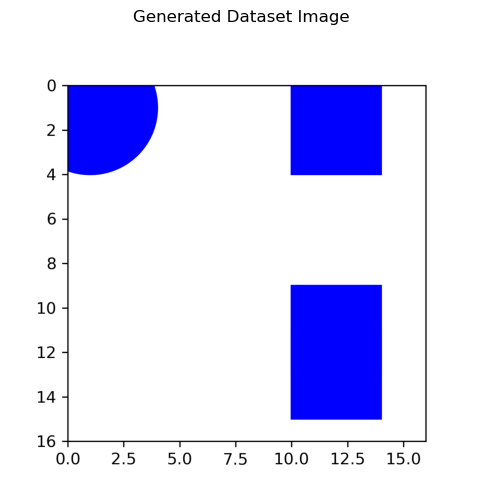

In [191]:
import matplotlib.pyplot as plt
import cv2

# Load an example image from the generated dataset
image_path = "./shapes_dataset_16x16/dataset/images/shapes_10.png"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Generated Dataset Image")
plt.show()

# Load and Inspect COCO Annotations

In [78]:
import json

# Select the dataset size to check
dataset_size = "16x16"  # Change to 128x128, 28x28, or 256x256

# Define annotation file path
annotation_file = f"./shapes_dataset_{dataset_size}/dataset/annotations/shapes_coco.json"

# Load and inspect annotations
with open(annotation_file, "r") as f:
    coco_data = json.load(f)

print(f"\n✅ Loaded {annotation_file}")
print(f" - Total Images: {len(coco_data['images'])}")
print(f" - Total Annotations: {len(coco_data['annotations'])}")

# Show first 2 annotations for verification
print("\n🔍 Sample Annotation:")
print(json.dumps(coco_data["annotations"][:2], indent=4))


✅ Loaded ./shapes_dataset_16x16/dataset/annotations/shapes_coco.json
 - Total Images: 100
 - Total Annotations: 317

🔍 Sample Annotation:
[
    {
        "id": 1,
        "image_id": 0,
        "category_id": 1,
        "segmentation": [
            [
                0.5,
                0.0,
                0.489840732818869,
                0.06088115047587815,
                0.4604638455118238,
                0.11516488362931271,
                0.41505277964795506,
                0.1569687146742241,
                0.35852852883889985,
                0.18176254986362445,
                0.2970163727239377,
                0.1868595924387506,
                0.23718210787756827,
                0.1717074987478233,
                0.18550970532017358,
                0.13794823325121222,
                0.14759867164878332,
                0.08924013619445131,
                0.12755725561198955,
                0.03086148567763763,
                0.12755725561198955,
         

# Visualizing Segmentation Masks on Sample Image

Total annotations for this image: 2
Segmentation Scaled: [[ 900.           75.        ]
 [ 887.80887938  148.05738057]
 [ 852.55661461  213.19786036]
 [ 798.06333558  263.36245761]
 [ 730.23423461  293.11505984]
 [ 656.41964727  299.23151093]
 [ 584.61852945  281.0489985 ]
 [ 522.61164638  240.5378799 ]
 [ 477.11840598  182.08816343]
 [ 453.06870673  112.03378281]
 [ 453.06870673   37.96621719]
 [ 477.11840598  -32.08816343]
 [ 522.61164638  -90.5378799 ]
 [ 584.61852945 -131.0489985 ]
 [ 656.41964727 -149.23151093]
 [ 730.23423461 -143.11505984]
 [ 798.06333558 -113.36245761]
 [ 852.55661461  -63.19786036]
 [ 887.80887938    1.94261943]
 [ 900.           75.        ]]
Segmentation Scaled: [[  0. 150.]
 [300. 150.]
 [300. 450.]
 [  0. 450.]]


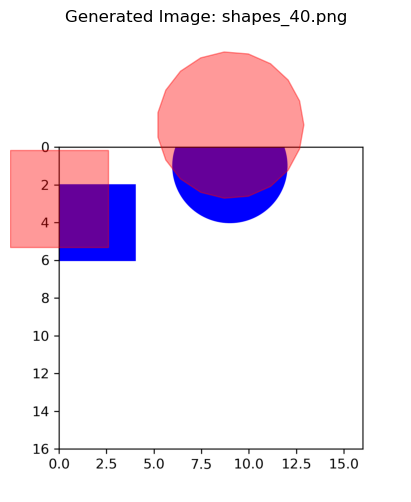

In [81]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import random

# Select a random image
image_info = random.choice(coco_data["images"])
image_filename = image_info["file_name"]
image_path = f"./shapes_dataset_16x16/dataset/images/{image_filename}"

# Load the image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get annotations for the selected image
image_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == image_info["id"]]

# Debugging: Ensure annotations exist
print(f"Total annotations for this image: {len(image_annotations)}")
if len(image_annotations) == 0:
    print("❌ No annotations found for this image.")

# Plot the image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(f"Generated Image: {image_filename}")

# Overlay segmentation masks
for ann in image_annotations:
    segmentation = np.array(ann["segmentation"][0]).reshape(-1, 2)  # Reshape into (N, 2)

    if np.max(segmentation) <= 1.0:  # If segmentation is normalized (0-1), scale to pixel coordinates
        segmentation *= np.array([[image.shape[1], image.shape[0]]])  # Scale correctly

    # Debugging: Check segmentation data
    print(f"Segmentation Scaled: {segmentation}")

    # Ensure integer values for plotting
    plt.fill(segmentation[:, 0].astype(int), segmentation[:, 1].astype(int), color="red", alpha=0.4)

plt.show()

# Load COCO Annotations & Visualize Random Image with Segmentation

#### Load, Display, and Overlay Segmentation Masks


🔍 Sample Annotation:
[
    {
        "id": 1,
        "image_id": 0,
        "category_id": 1,
        "segmentation": [
            [
                0.5,
                0.0,
                0.489840732818869,
                0.06088115047587815,
                0.4604638455118238,
                0.11516488362931271,
                0.41505277964795506,
                0.1569687146742241,
                0.35852852883889985,
                0.18176254986362445,
                0.2970163727239377,
                0.1868595924387506,
                0.23718210787756827,
                0.1717074987478233,
                0.18550970532017358,
                0.13794823325121222,
                0.14759867164878332,
                0.08924013619445131,
                0.12755725561198955,
                0.03086148567763763,
                0.12755725561198955,
                -0.030861485677637586,
                0.1475986716487833,
                -0.08924013619445129,
             

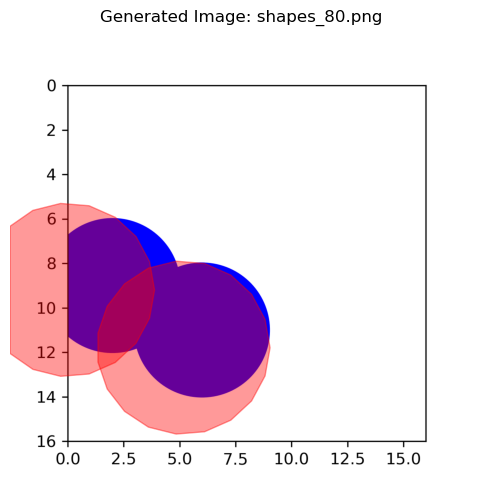

In [215]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import json
import random
import os

# Choose dataset size
dataset_size = "16x16"  # Change to other resolutions as needed

# Define paths
images_dir = f"./shapes_dataset_{dataset_size}/dataset/images"
annotations_file = f"./shapes_dataset_{dataset_size}/dataset/annotations/shapes_coco.json"

# ✅ Load COCO annotation data
with open(annotations_file, "r") as f:
    coco_data = json.load(f)

# ✅ Print first 5 annotations for debugging
print("\n🔍 Sample Annotation:")
print(json.dumps(coco_data["annotations"][:5], indent=4))  # Check first 5 entries

# Pick a random image
image_info = random.choice(coco_data["images"])
image_filename = image_info["file_name"]
image_path = os.path.join(images_dir, image_filename)

# Load the image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get annotations for the selected image
image_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == image_info["id"]]

# Plot the image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(f"Generated Image: {image_filename}")

# Overlay segmentation masks
for ann in image_annotations:
    segmentation = np.array(ann["segmentation"][0])

    # Reshape to Nx2 format
    segmentation = segmentation.reshape(-1, 2)

    # Check if segmentation is normalized (0-1) and scale properly
    if np.max(segmentation) <= 1.0:
        print("⚠️ Scaling normalized segmentation to pixel coordinates...")
        segmentation *= np.array([image.shape[1], image.shape[0]])

    # ✅ Ensure segmentation stays within image bounds
    segmentation[:, 0] = np.clip(segmentation[:, 0], 0, image.shape[1] - 1)
    segmentation[:, 1] = np.clip(segmentation[:, 1], 0, image.shape[0] - 1)

    # Convert to int
    segmentation = segmentation.astype(np.int32)

    # Overlay segmentation in red
    plt.fill(segmentation[:, 0], segmentation[:, 1], color="red", alpha=0.4)

plt.show()

#### Resize Image to 16x16

In [218]:
image = cv2.resize(image, (16, 16), interpolation=cv2.INTER_NEAREST)
print(f"Resized image shape: {image.shape}")  # Should output (16,16,3)

Resized image shape: (16, 16, 3)


#### Convert and Scale Segmentation to Match 16x16 Image

In [221]:
# Convert segmentation to a NumPy array
segmentation = np.array(ann["segmentation"][0])

# Print original segmentation before scaling
print(f"Original Segmentation (Before Scaling): {segmentation}")

# Reshape segmentation into (N, 2) format
segmentation = segmentation.reshape(-1, 2)  # Now it's (N,2), not (40,)

# If segmentation is normalized (0-1), scale directly to 16x16
if np.max(segmentation) <= 1.0:
    print("⚠️ Scaling normalized segmentation to 16x16...")
    segmentation *= 16  # Directly scale

# Convert to integer format for pixel coordinates
segmentation = segmentation.astype(np.int32)

# Print scaled segmentation
print(f"✅ Scaled Segmentation (After Scaling): {segmentation}")


# Convert to integer format for pixel coordinates
segmentation = segmentation.astype(np.int32)

# Print scaled segmentation
print(f"Scaled Segmentation (After Scaling): {segmentation}")

Original Segmentation (Before Scaling): [ 0.3125      0.5625      0.30234073  0.62338115  0.27296385  0.67766488
  0.22755278  0.71946871  0.17102853  0.74426255  0.10951637  0.74935959
  0.04968211  0.7342075  -0.00199029  0.70044823 -0.03990133  0.65174014
 -0.05994274  0.59336149 -0.05994274  0.53163851 -0.03990133  0.47325986
 -0.00199029  0.42455177  0.04968211  0.3907925   0.10951637  0.37564041
  0.17102853  0.38073745  0.22755278  0.40553129  0.27296385  0.44733512
  0.30234073  0.50161885  0.3125      0.5625    ]
⚠️ Scaling normalized segmentation to 16x16...
✅ Scaled Segmentation (After Scaling): [[ 5  9]
 [ 4  9]
 [ 4 10]
 [ 3 11]
 [ 2 11]
 [ 1 11]
 [ 0 11]
 [ 0 11]
 [ 0 10]
 [ 0  9]
 [ 0  8]
 [ 0  7]
 [ 0  6]
 [ 0  6]
 [ 1  6]
 [ 2  6]
 [ 3  6]
 [ 4  7]
 [ 4  8]
 [ 5  9]]
Scaled Segmentation (After Scaling): [[ 5  9]
 [ 4  9]
 [ 4 10]
 [ 3 11]
 [ 2 11]
 [ 1 11]
 [ 0 11]
 [ 0 11]
 [ 0 10]
 [ 0  9]
 [ 0  8]
 [ 0  7]
 [ 0  6]
 [ 0  6]
 [ 1  6]
 [ 2  6]
 [ 3  6]
 [ 4  7]
 [ 4  

## Load Model

#### Set Up Torch Device for Model Execution

In [225]:
import torch

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"

#### Load SAM Model from Checkpoint

In [228]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)

## Automated Mask Generation

To run automatic mask generation, provide a SAM model to the `SamAutomaticMaskGenerator` class. Set the path below to the SAM checkpoint. Running on CUDA and with the default model is recommended.

#### Initialize SAM Mask Generator

In [231]:
mask_generator = SamAutomaticMaskGenerator(sam)

#### Select a Random Image from the 16x16 Dataset for Testing

In [233]:
import os
import random

# Correct dataset path
dataset_size = "16x16"
IMAGES_DIRECTORY_PATH = f"/Users/ma/Documents/samThesis/segment-anything/notebooks/shapes/shapes_dataset_{dataset_size}/dataset/images"

# Ensure directory exists before selecting an image
if os.path.exists(IMAGES_DIRECTORY_PATH) and os.listdir(IMAGES_DIRECTORY_PATH):
    IMAGE_NAME = random.choice(os.listdir(IMAGES_DIRECTORY_PATH))
    IMAGE_PATH = os.path.join(IMAGES_DIRECTORY_PATH, IMAGE_NAME)
    print(f"✅ Using Image: {IMAGE_PATH}")
else:
    print(f"❌ ERROR: No images found in {IMAGES_DIRECTORY_PATH}")

✅ Using Image: /Users/ma/Documents/samThesis/segment-anything/notebooks/shapes/shapes_dataset_16x16/dataset/images/shapes_73.png


### Generate masks with SAM

#### import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot Ground Truth Mask
plt.subplot(1, 2, 1)
plt.imshow(gt_mask, cmap='gray')
plt.title("Ground Truth Mask")
plt.axis("off")

# Plot Predicted Mask
plt.subplot(1, 2, 2)
plt.imshow(predicted_mask, cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")

plt.show() 

# single-run segmentation evaluation.

#### Generate Segmentation Masks and Compare with Ground Truth

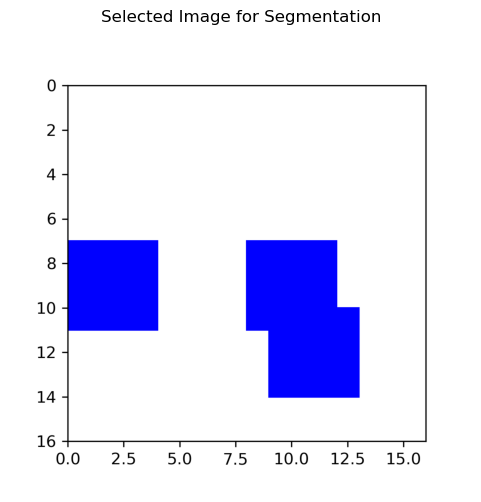

✅ Total detected masks: 21
✅ GT Mask Resized Shape: torch.Size([16, 16])
⚠️ Resizing predicted_mask from torch.Size([1200, 1200]) to (16, 16)
✅ Predicted Mask Resized Shape: torch.Size([16, 16])
🔹 IoU: 0.0192, Dice Score: 0.0377


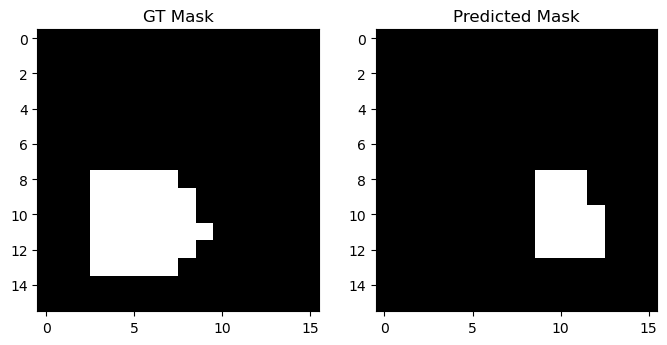

In [238]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Toggle debugging prints
DEBUG = False  # Set to True to enable detailed debugging

# Load the selected image
image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Display the selected image before segmentation
plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("Selected Image for Segmentation")
plt.axis("off")
plt.show()

# Generate segmentation masks using SAM
sam_result = mask_generator.generate(image_rgb)

print(f"✅ Total detected masks: {len(sam_result)}")

# Extract the predicted mask (assuming first mask)
predicted_mask = sam_result[0]['segmentation']
predicted_mask = torch.tensor(predicted_mask).bool()

# Load the ground truth mask from COCO annotations
gt_mask = None
for ann in coco_data["annotations"]:
    if ann["image_id"] == image_info["id"]:
        gt_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

        # Extract segmentation points
        segmentation = np.array(ann["segmentation"][0])

        if DEBUG:
            print(f"🔍 Original Segmentation Shape: {segmentation.shape}, Values: {segmentation[:8]}")

        # Ensure segmentation has an even number of coordinates (x, y pairs)
        if len(segmentation) % 2 != 0:
            raise ValueError("Segmentation mask does not have an even number of coordinates!")

        # Reshape into (N,2) format
        segmentation = segmentation.reshape(-1, 2)

        # Scale segmentation to pixel coordinates if it's normalized
        if np.max(segmentation) <= 1.0:
            if DEBUG:
                print("⚠️ Detected normalized COCO annotations, scaling to pixel coordinates...")
            segmentation *= np.array([image.shape[1], image.shape[0]])  # Scale up

        # Convert to int for OpenCV
        segmentation = segmentation.astype(np.int32)

        # Fill the polygon to create the mask
        cv2.fillPoly(gt_mask, [segmentation], color=1)

        # Convert to tensor
        gt_mask = torch.tensor(gt_mask).bool()
        break

# Ensure ground truth mask exists
if gt_mask is not None:
    if DEBUG:
        print(f"⚠️ GT Mask Original Shape: {gt_mask.shape}")

    # Resize gt_mask to match 16x16 if needed
    if gt_mask.shape[-2:] != (16, 16):
        print(f"⚠️ Resizing gt_mask from {gt_mask.shape} to (16, 16)")
        gt_mask = F.interpolate(gt_mask.unsqueeze(0).unsqueeze(0).float(), 
                                size=(16, 16), mode="nearest").squeeze(0).squeeze(0).bool()
    
    print(f"✅ GT Mask Resized Shape: {gt_mask.shape}")

    # Ensure predicted mask is also 16x16
    if predicted_mask.shape[-2:] != (16, 16):
        print(f"⚠️ Resizing predicted_mask from {predicted_mask.shape} to (16, 16)")
        predicted_mask = F.interpolate(predicted_mask.unsqueeze(0).unsqueeze(0).float(), 
                                       size=(16, 16), mode="nearest").squeeze(0).squeeze(0).bool()

    print(f"✅ Predicted Mask Resized Shape: {predicted_mask.shape}")

    # Compute IoU & Dice Score
    iou_score = compute_iou(predicted_mask, gt_mask)
    dice_score = compute_dice(predicted_mask, gt_mask)

    # Print the results
    print(f"🔹 IoU: {iou_score:.4f}, Dice Score: {dice_score:.4f}")

    # Plot the masks for verification
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(gt_mask.cpu().numpy(), cmap="gray")
    plt.title("GT Mask")

    plt.subplot(1, 2, 2)
    plt.imshow(predicted_mask.cpu().numpy(), cmap="gray")
    plt.title("Predicted Mask")

    plt.show()
else:
    print("❌ No ground truth mask found for this image.")

#### Inspect SAM Output Keys for Further Processing

In [240]:
print("SAM Result Keys:", list(sam_result[0].keys()))

SAM Result Keys: ['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box']


#### Overlay Ground Truth & Predicted Masks for Comparison

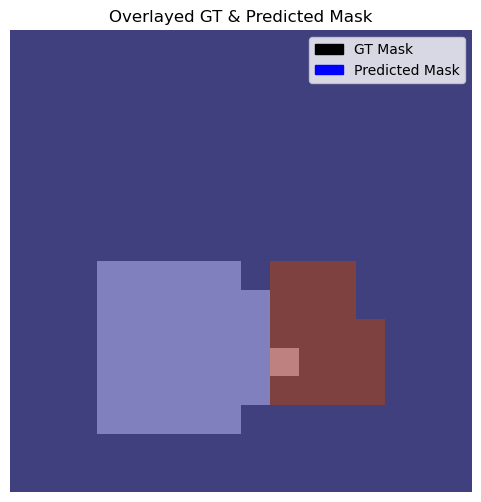

In [242]:
# Overlay Ground Truth & Predicted Masks for Comparison
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.figure(figsize=(6, 6))

# Display GT mask in grayscale
plt.imshow(gt_mask.cpu().numpy(), cmap="gray", alpha=0.5)

# Display predicted mask in jet colormap
plt.imshow(predicted_mask.cpu().numpy(), cmap="jet", alpha=0.5)

# Add a manual legend
legend_patches = [
    Patch(color="black", label="GT Mask"), 
    Patch(color="blue", label="Predicted Mask")
]
plt.legend(handles=legend_patches, loc="upper right")

plt.title("Overlayed GT & Predicted Mask")
plt.axis("off")
plt.show()

### Output format

`SamAutomaticMaskGenerator` returns a `list` of masks, where each mask is a `dict` containing various information about the mask:

* `segmentation` - `[np.ndarray]` - the mask with `(W, H)` shape, and `bool` type
* `area` - `[int]` - the area of the mask in pixels
* `bbox` - `[List[int]]` - the boundary box of the mask in `xywh` format
* `predicted_iou` - `[float]` - the model's own prediction for the quality of the mask
* `point_coords` - `[List[List[float]]]` - the sampled input point that generated this mask
* `stability_score` - `[float]` - an additional measure of mask quality
* `crop_box` - `List[int]` - the crop of the image used to generate this mask in `xywh` format

### Results visualisation with Supervision

As of version `0.5.0` Supervision has native support for SAM.

#### Annotate and Visualize Segmentation Masks

✅ Total detected masks: 21


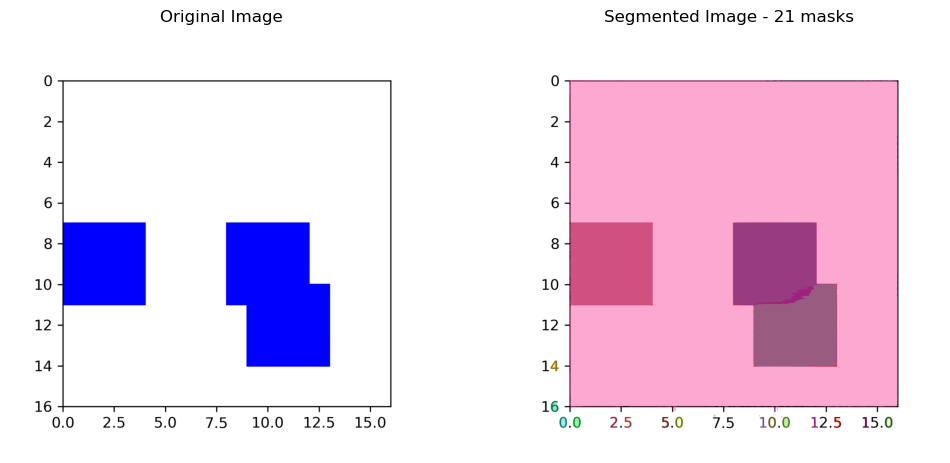

In [247]:
import supervision as sv
import matplotlib.pyplot as plt

print(f"✅ Total detected masks: {len(sam_result)}")

# Create a mask annotator
mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)

# Convert SAM output to supervision-compatible format
detections = sv.Detections.from_sam(sam_result=sam_result)  # Use all masks, no filtering

# Annotate the image with segmentation masks
annotated_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

# Display original and segmented images side by side
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

# Segmented Image
plt.subplot(1, 2, 2)
plt.imshow(annotated_image)
plt.title(f"Segmented Image - {len(sam_result)} masks")
plt.axis("off")

plt.show()


### Interaction with segmentation results

#### Display All Generated Masks in a Grid

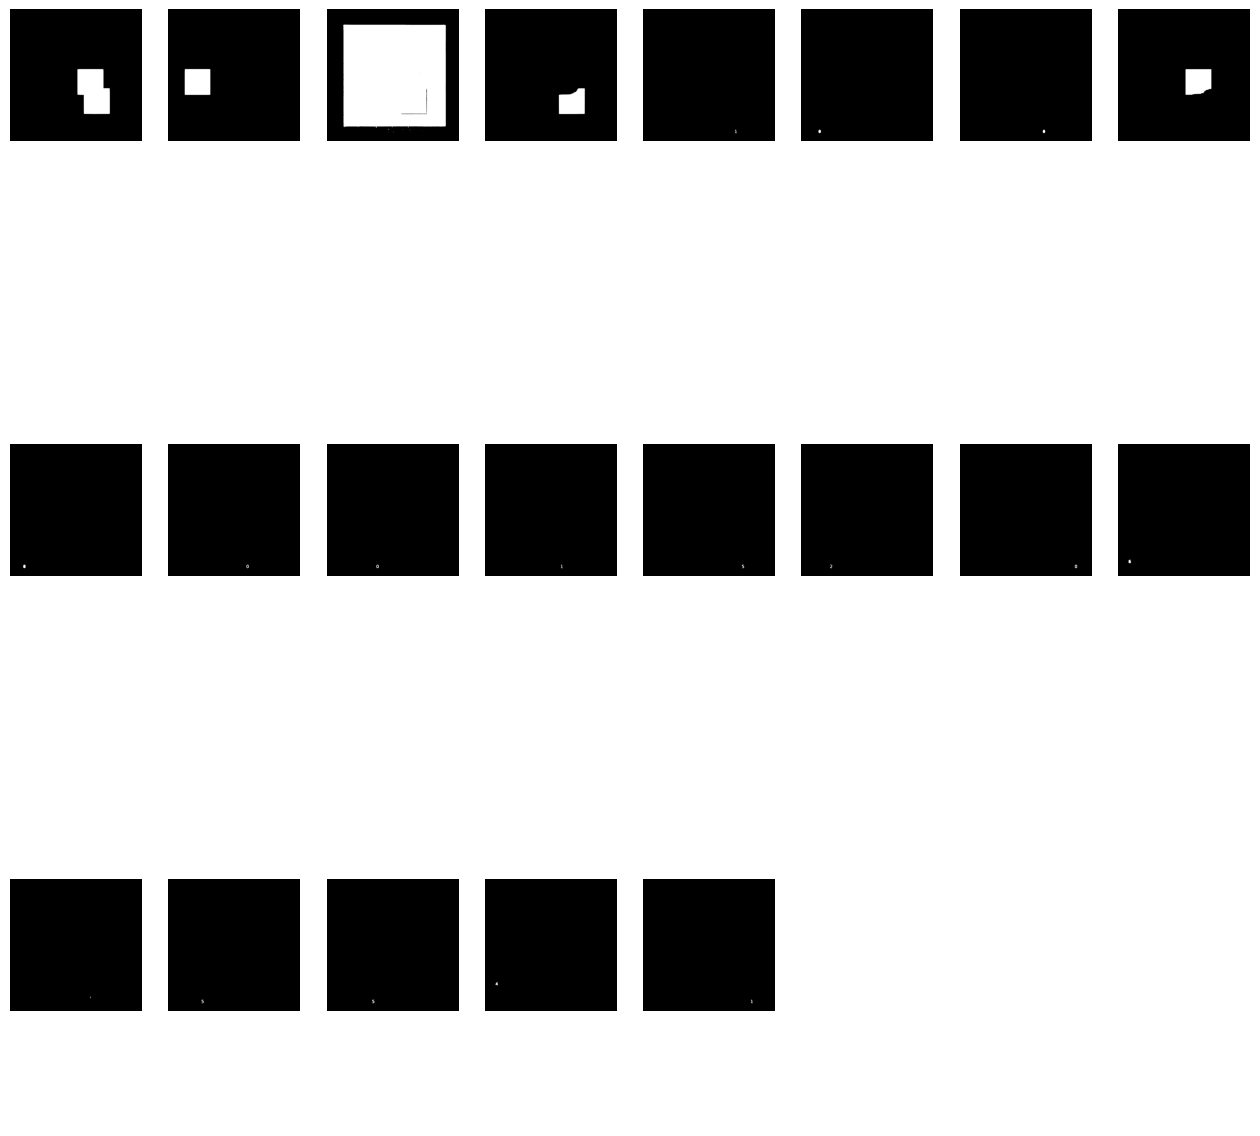

In [250]:
# Show all masks without filtering
masks = [mask['segmentation'] for mask in sam_result]

# Calculate grid size dynamically
num_masks = len(masks)
grid_cols = min(8, num_masks)  # Limit columns to a max of 8
grid_rows = (num_masks // grid_cols) + (num_masks % grid_cols > 0)  # Ensure all images fit

# Display masks in a properly sized grid
sv.plot_images_grid(
    images=masks,
    grid_size=(grid_rows, grid_cols),  # Auto-adjusted grid size
    size=(16, 16)
)

## Generate Segmentation with Bounding Box

The `SamPredictor` class provides an easy interface to the model for prompting the model. It allows the user to first set an image using the `set_image` method, which calculates the necessary image embeddings. Then, prompts can be provided via the `predict` method to efficiently predict masks from those prompts. The model can take as input both point and box prompts, as well as masks from the previous iteration of prediction.

In [252]:
mask_predictor = SamPredictor(sam)

#### Load and Verify Dataset Image Files

In [254]:
import os
import random

# Verify the images directory exists
if not os.path.exists(IMAGES_DIRECTORY_PATH):
    raise FileNotFoundError(f"❌ The specified images directory does not exist: {IMAGES_DIRECTORY_PATH}")
else:
    # Load image filenames
    IMAGES = os.listdir(IMAGES_DIRECTORY_PATH)

    if len(IMAGES) == 0:
        print("❌ ERROR: No images found in the dataset folder.")
    else:
        # Pick a random image
        IMAGE_NAME = random.choice(IMAGES)
        IMAGE_PATH = os.path.join(IMAGES_DIRECTORY_PATH, IMAGE_NAME)

        print(f"✅ Using Image: {IMAGE_PATH}")

✅ Using Image: /Users/ma/Documents/samThesis/segment-anything/notebooks/shapes/shapes_dataset_16x16/dataset/images/shapes_2.png


# epochs-based segmentation experiment


🚀 Epoch 1/10 running...

✅ Total detected masks: 22
🔹 Epoch 1 - IoU: 0.1572, Dice Score: 0.2717


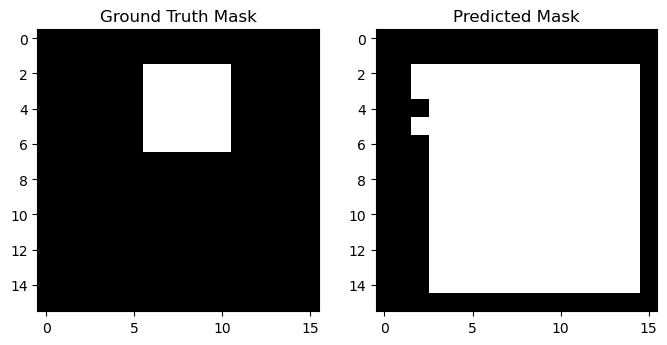


🚀 Epoch 2/10 running...

✅ Total detected masks: 25
🔹 Epoch 2 - IoU: 0.3600, Dice Score: 0.5294


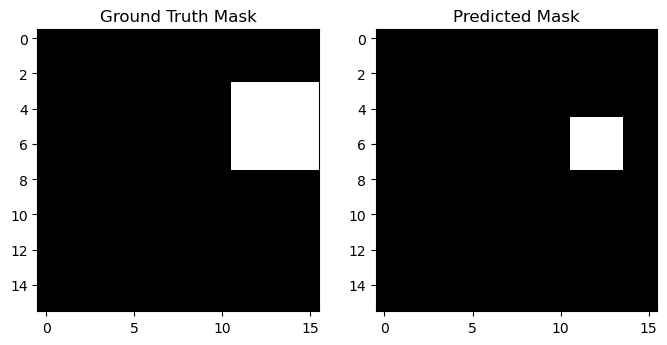


🚀 Epoch 3/10 running...

✅ Total detected masks: 25
🔹 Epoch 3 - IoU: 0.0000, Dice Score: 0.0000


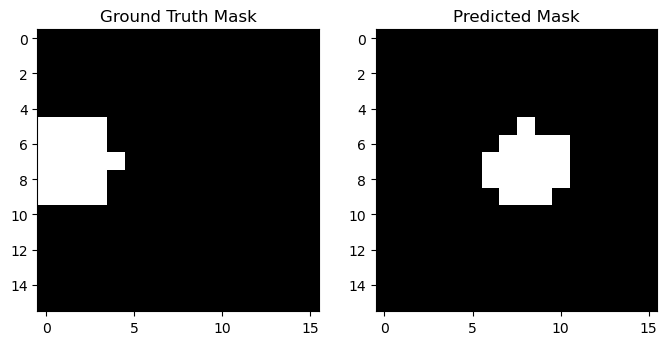


🚀 Epoch 4/10 running...

✅ Total detected masks: 23
🔹 Epoch 4 - IoU: 0.0093, Dice Score: 0.0184


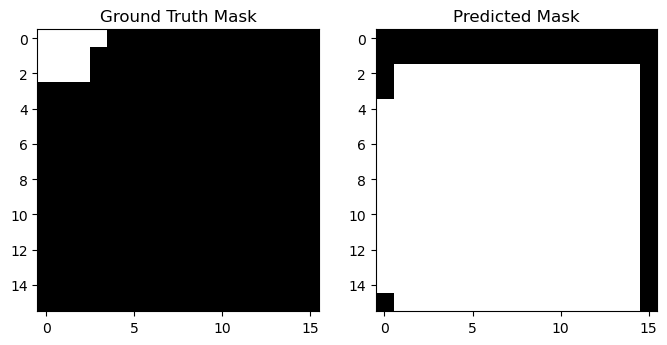


🚀 Epoch 5/10 running...

✅ Total detected masks: 20
🔹 Epoch 5 - IoU: 0.0000, Dice Score: 0.0000


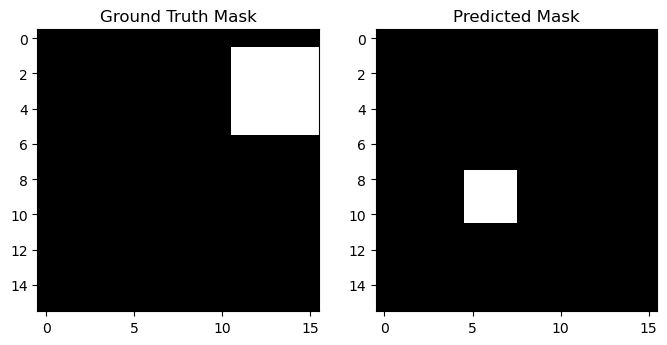


🚀 Epoch 6/10 running...

✅ Total detected masks: 20
🔹 Epoch 6 - IoU: 0.3600, Dice Score: 0.5294


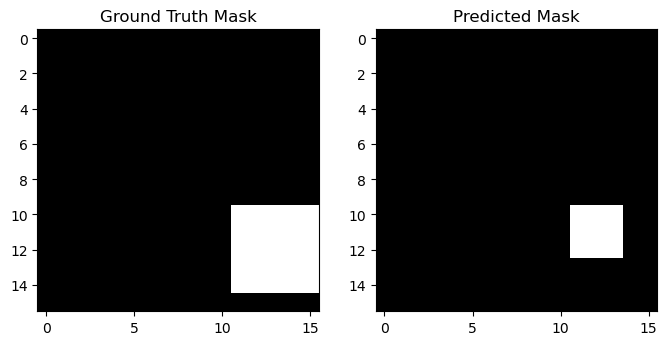


🚀 Epoch 7/10 running...

✅ Total detected masks: 20
🔹 Epoch 7 - IoU: 0.0000, Dice Score: 0.0000


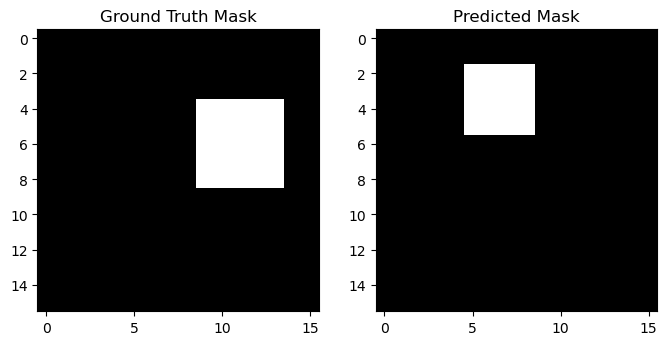


🚀 Epoch 8/10 running...

✅ Total detected masks: 21
🔹 Epoch 8 - IoU: 0.6154, Dice Score: 0.7619


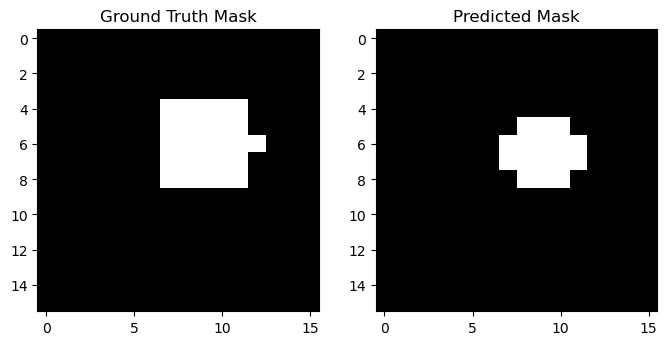


🚀 Epoch 9/10 running...

✅ Total detected masks: 21
🔹 Epoch 9 - IoU: 0.0000, Dice Score: 0.0000


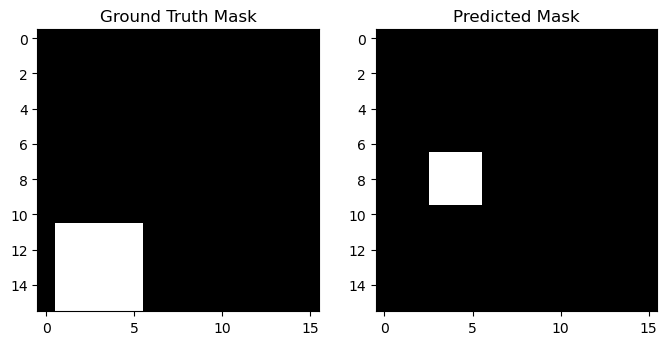


🚀 Epoch 10/10 running...

✅ Total detected masks: 23
🔹 Epoch 10 - IoU: 0.0000, Dice Score: 0.0000


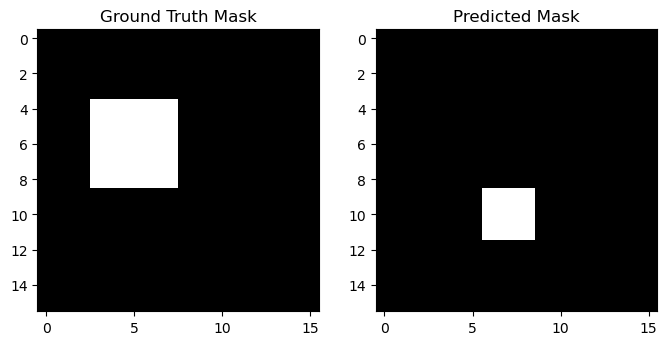


📊 **Epoch Results Summary**
Epoch 1: shapes_93.png -> IoU: 0.1572, Dice: 0.2717
Epoch 2: shapes_83.png -> IoU: 0.3600, Dice: 0.5294
Epoch 3: shapes_38.png -> IoU: 0.0000, Dice: 0.0000
Epoch 4: shapes_91.png -> IoU: 0.0093, Dice: 0.0184
Epoch 5: shapes_30.png -> IoU: 0.0000, Dice: 0.0000
Epoch 6: shapes_88.png -> IoU: 0.3600, Dice: 0.5294
Epoch 7: shapes_20.png -> IoU: 0.0000, Dice: 0.0000
Epoch 8: shapes_50.png -> IoU: 0.6154, Dice: 0.7619
Epoch 9: shapes_21.png -> IoU: 0.0000, Dice: 0.0000
Epoch 10: shapes_69.png -> IoU: 0.0000, Dice: 0.0000


In [256]:
import torch
import numpy as np
import random
import cv2
import matplotlib.pyplot as plt

# Define number of epochs
NUM_EPOCHS = 10  # Change as needed

# Store results for each epoch
epoch_results = []

# Loop over multiple epochs
for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n🚀 Epoch {epoch}/{NUM_EPOCHS} running...\n")

    # Select a random image
    image_info = random.choice(coco_data["images"])
    image_filename = image_info["file_name"]
    image_path = f"./shapes_dataset_16x16/dataset/images/{image_filename}"

    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Get annotations
    image_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == image_info["id"]]
    
    if len(image_annotations) == 0:
        print("❌ No annotations found for this image. Skipping...")
        continue

    # Run SAM to generate segmentation masks
    sam_result = mask_generator.generate(image)

    print(f"✅ Total detected masks: {len(sam_result)}")

    # Extract the first predicted mask
    predicted_mask = sam_result[0]['segmentation']
    predicted_mask = torch.tensor(predicted_mask).bool()

    # Load ground truth mask
    gt_mask = None
    for ann in image_annotations:
        gt_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        segmentation = np.array(ann["segmentation"][0]).reshape(-1, 2)

        # Scale segmentation if needed
        if np.max(segmentation) <= 1.0:
            segmentation *= np.array([image.shape[1], image.shape[0]])
        segmentation = segmentation.astype(np.int32)

        # Create the ground truth mask
        cv2.fillPoly(gt_mask, [segmentation], color=1)
        gt_mask = torch.tensor(gt_mask).bool()
        break  # Process only one annotation per image

    # Resize ground truth mask if needed
    if gt_mask.shape[-2:] != (16, 16):
        gt_mask = torch.nn.functional.interpolate(
            gt_mask.unsqueeze(0).unsqueeze(0).float(),
            size=(16, 16), mode="nearest"
        ).squeeze(0).squeeze(0).bool()

    # Resize predicted mask if needed
    if predicted_mask.shape[-2:] != (16, 16):
        predicted_mask = torch.nn.functional.interpolate(
            predicted_mask.unsqueeze(0).unsqueeze(0).float(),
            size=(16, 16), mode="nearest"
        ).squeeze(0).squeeze(0).bool()

    # Compute IoU & Dice Scores
    iou_score = compute_iou(predicted_mask, gt_mask)
    dice_score = compute_dice(predicted_mask, gt_mask)

    # Store results
    epoch_results.append({
        "epoch": epoch,
        "image": image_filename,
        "iou": iou_score,
        "dice": dice_score
    })

    # Print metrics
    print(f"🔹 Epoch {epoch} - IoU: {iou_score:.4f}, Dice Score: {dice_score:.4f}")

    # Plot for visualization
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(gt_mask.cpu().numpy(), cmap="gray")
    plt.title("Ground Truth Mask")

    plt.subplot(1, 2, 2)
    plt.imshow(predicted_mask.cpu().numpy(), cmap="gray")
    plt.title("Predicted Mask")

    plt.show()

# Print all epoch results
print("\n📊 **Epoch Results Summary**")
for result in epoch_results:
    print(f"Epoch {result['epoch']}: {result['image']} -> IoU: {result['iou']:.4f}, Dice: {result['dice']:.4f}")
